In [261]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator # This is the automatic elbow-finder from your lab
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Importing Data

In [262]:
rent_df = pd.read_csv("apartments_for_rent_classified_10K.csv", sep=';', encoding='latin1', na_values=['null'])
rent_df.drop(columns=['id'], inplace=True)
rent_df.head()

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,NaN,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [263]:
rent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       10000 non-null  object 
 1   title          10000 non-null  object 
 2   body           10000 non-null  object 
 3   amenities      6451 non-null   object 
 4   bathrooms      9966 non-null   float64
 5   bedrooms       9993 non-null   float64
 6   currency       10000 non-null  object 
 7   fee            10000 non-null  object 
 8   has_photo      10000 non-null  object 
 9   pets_allowed   5837 non-null   object 
 10  price          10000 non-null  int64  
 11  price_display  10000 non-null  object 
 12  price_type     10000 non-null  object 
 13  square_feet    10000 non-null  int64  
 14  address        6673 non-null   object 
 15  cityname       9923 non-null   object 
 16  state          9923 non-null   object 
 17  latitude       9990 non-null   float64
 18  longitu

In [264]:
rent_df.describe()

,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [265]:
rent_df.isna().sum()

category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     4163
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [266]:
cols_to_drop = ['id', 'title', 'body', 'address', 'currency', 'fee', 'category', 
                'price_type', 'price_display', 'cityname', 'state', 'has_photo', 
                'time', 'bathrooms', 'bedrooms']

rent_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
rent_df.dropna(subset=['latitude', 'longitude'], inplace=True)

rent_df.head()

,amenities,pets_allowed,price,square_feet,latitude,longitude,source
0,NaN,NaN,790,101,38.9057,-76.9861,RentLingo
1,NaN,NaN,425,106,37.9680,-87.6621,RentLingo
2,NaN,NaN,1390,107,38.8910,-77.0816,RentLingo
3,NaN,NaN,925,116,47.6160,-122.3275,RentLingo
4,NaN,NaN,880,125,38.8738,-77.1055,RentLingo


In [267]:
# Fill NaN values in 'amenities' with empty strings
rent_df['amenities'] = rent_df['amenities'].fillna(' ')

# Get counts of ALL individual amenities across the dataset
amenity_counts = Counter()
rent_df['amenities'].str.split(',').apply(amenity_counts.update)

# Select the Top 15 most common amenities
top_n = 15
top_amenities = [amenity for amenity, count in amenity_counts.most_common(top_n)]

# Create new binary columns for each top amenity (0 and 1 values)
for amenity in top_amenities:
    rent_df[f'amenity_{amenity}'] = rent_df['amenities'].str.contains(amenity, case=False, na=False).astype(int)

#Drop the original amenities column
rent_df_engineered = rent_df.drop(columns=['amenities'])

In [268]:
# One-hot encode source and pets_allowed columns
rent_df_encoded = pd.get_dummies(rent_df_engineered, columns=['source', 'pets_allowed'], dtype=int)
rent_df_encoded.head()

,price,square_feet,latitude,longitude,amenity_Parking,amenity_,amenity_Dishwasher,amenity_Pool,amenity_Refrigerator,amenity_Patio/Deck,...,source_RENTOCULAR,source_Real Estate Agent,source_RealRentals,source_RentDigs.com,source_RentLingo,source_rentbits,source_tenantcloud,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs
0,790,101,38.9057,-76.9861,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,425,106,37.9680,-87.6621,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,1390,107,38.8910,-77.0816,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,925,116,47.6160,-122.3275,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,880,125,38.8738,-77.1055,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [269]:
rent_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9990 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   price                       9990 non-null   int64  
 1   square_feet                 9990 non-null   int64  
 2   latitude                    9990 non-null   float64
 3   longitude                   9990 non-null   float64
 4   amenity_Parking             9990 non-null   int32  
 5   amenity_                    9990 non-null   int32  
 6   amenity_Dishwasher          9990 non-null   int32  
 7   amenity_Pool                9990 non-null   int32  
 8   amenity_Refrigerator        9990 non-null   int32  
 9   amenity_Patio/Deck          9990 non-null   int32  
 10  amenity_Cable or Satellite  9990 non-null   int32  
 11  amenity_Storage             9990 non-null   int32  
 12  amenity_Gym                 9990 non-null   int32  
 13  amenity_Internet Access     9990 non-n

# EDA

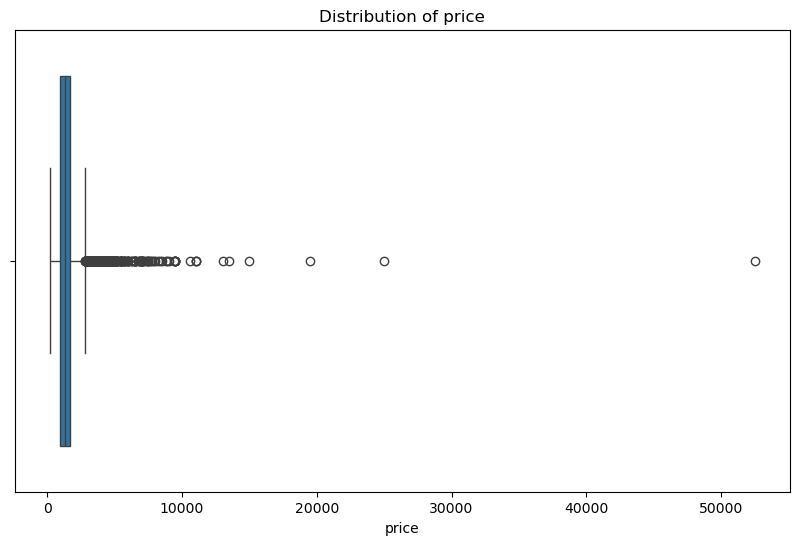

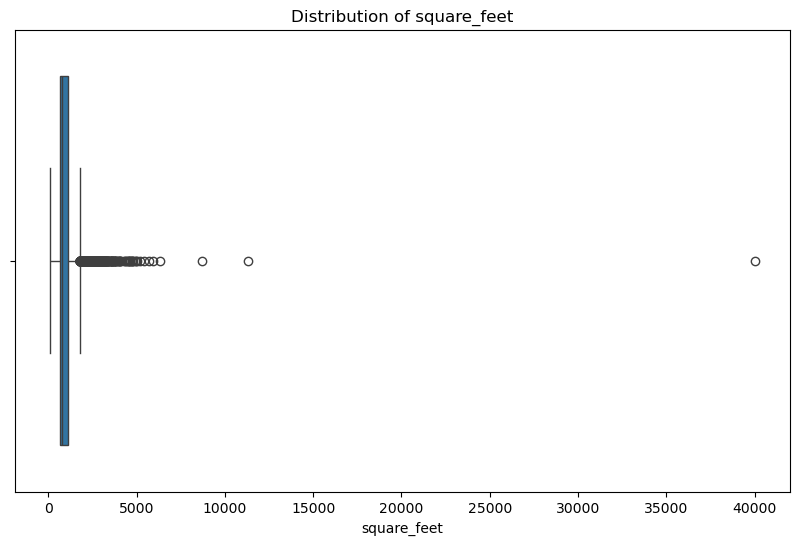

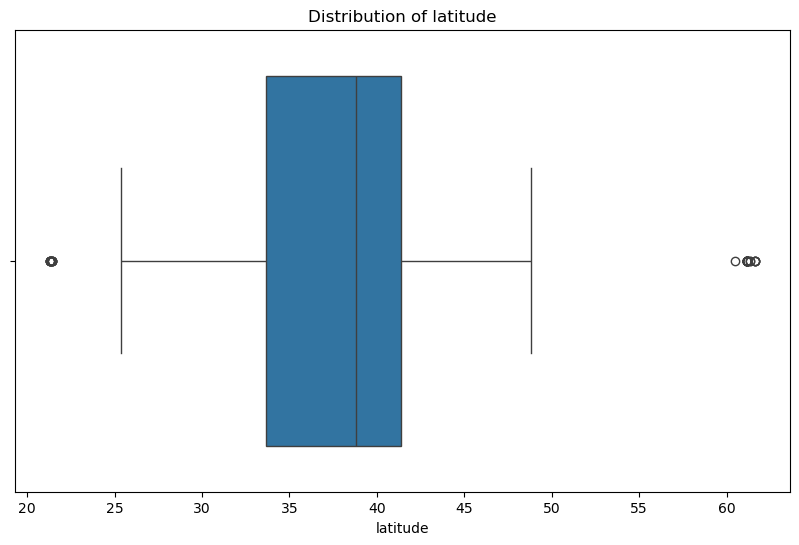

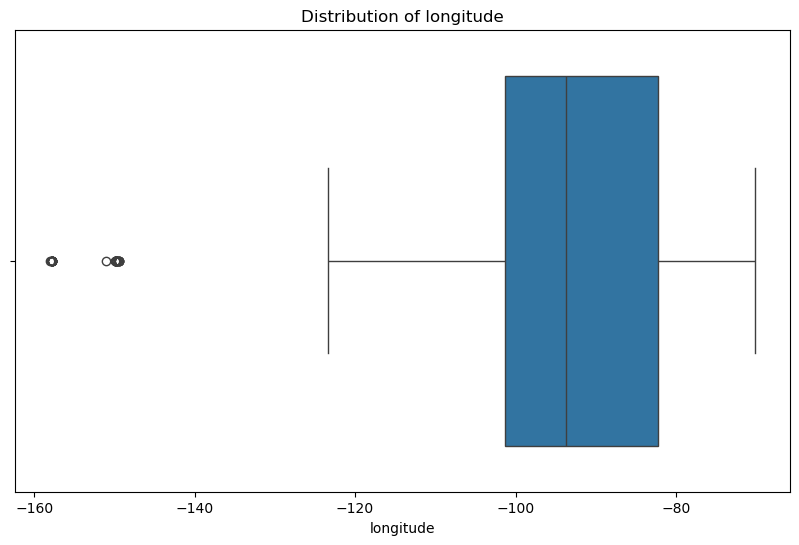

In [270]:
num_cols = rent_df.select_dtypes(include=[np.number]).columns[:4]
for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=rent_df, x=col, orient='h')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

In [271]:
# scale dataset with Robust Scaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaled_data = scaler.fit_transform(rent_df_encoded)
scaled_df = pd.DataFrame(scaled_data,columns=rent_df_encoded.columns)
scaled_df.head()

,price,square_feet,latitude,longitude,amenity_Parking,amenity_,amenity_Dishwasher,amenity_Pool,amenity_Refrigerator,amenity_Patio/Deck,...,source_RENTOCULAR,source_Real Estate Agent,source_RealRentals,source_RentDigs.com,source_RentLingo,source_rentbits,source_tenantcloud,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs
0,-0.644102,-1.556541,0.012503,0.872917,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
1,-1.133378,-1.545455,-0.109753,0.313722,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
2,0.160188,-1.543237,0.010587,0.867915,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
3,-0.463137,-1.523282,1.148143,-1.502007,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
4,-0.523458,-1.503326,0.008344,0.866663,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0


## K-means algorithm

In [272]:
# --- Make sure you have these imports ---
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# --- Here is the corrected code ---
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(2, 10)

for k in K:
    # Changed scaled_data to scaled_df
    kmeanmodel = KMeans(n_clusters=k, random_state=42).fit(scaled_df)
    
    distortions.append(
        sum(
            # Changed scaled_data to scaled_df
            np.min(cdist(scaled_df, kmeanmodel.cluster_centers_, 'euclidean'), axis=1)
        ) / scaled_df.shape[0] # Changed scaled_data to scaled_df
    )
    inertias.append(kmeanmodel.inertia_)
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

# check the inertia for each K
print("--- Inertia (SSE) for each K ---")
for key, val in mapping2.items():
    print(f"{key} : {val}")

--- Inertia (SSE) for each K ---
2 : 71484.59183137771
3 : 66406.66284798765
4 : 60897.151096856935
5 : 53758.83916437344
6 : 49449.00940448429
7 : 46116.85010804716
8 : 44773.27440140088
9 : 41009.551647427266


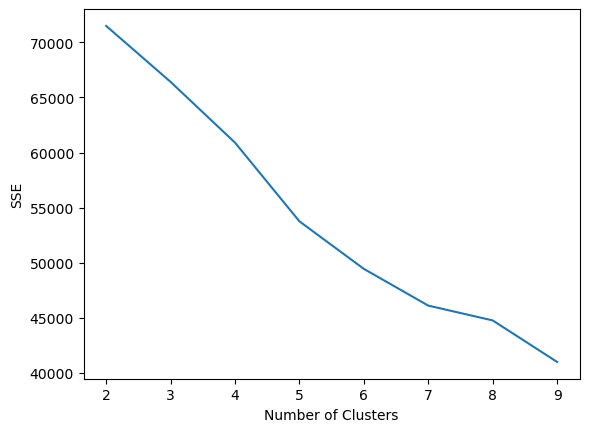

In [273]:
plt.plot(range(2, 10), inertias)
plt.xticks(range(2, 10))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [274]:
#Silhouette coefficients
silhouette_coefficients = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_coefficients.append(score)


Text(0, 0.5, 'Silhouette Coefficient')

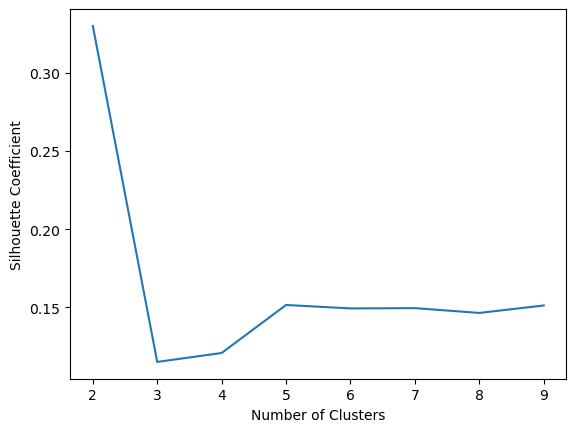

In [275]:
plt.plot(range(2,10), silhouette_coefficients)
plt.xticks(range(2, 10))

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")